In [ ]:
import pandas as pd

In [ ]:
def import_csv(url, date_cols=None):
    path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
    return pd.read_csv(path, parse_dates=date_cols)

# orders_cl.csv
orders_url = "https://drive.google.com/file/d/1clMQ_JgII9h6FX931gFN5bjqstwR2FNe/view?usp=drive_link"


# orderlines_cl.csv
orderlines_url = "https://drive.google.com/file/d/1L8q-smVIRmn_SpGgDfsVtDZ_7-wtda-j/view?usp=drive_link"


# products_cl.csv
products_url = "https://drive.google.com/file/d/1EEwu-HCrbFSYNO7mloYIHUKf4JuO2cSG/view?usp=drive_link"

orders_df = import_csv(orders_url, ["created_date"])
orderlines_df = import_csv(orderlines_url, ["date"])
products_df = import_csv(products_url)
print("Orders:", orders_df.shape[0])
print("Orderlines:", orderlines_df.shape[0])

Orders: 226904
Orderlines: 216250


In [ ]:
import pandas as pd

# products_cl.csv
url = "https://drive.google.com/file/d/1EEwu-HCrbFSYNO7mloYIHUKf4JuO2cSG/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [ ]:
orderlines_df.dtypes

,0
order_id,int64
product_quantity,int64
sku,object
unit_price,float64
date,datetime64[ns]
unit_total,float64


In [ ]:
# Keep only completed orders
completed_orders = orders_df.loc[
    orders_df["state"] == "Completed"
].copy()
completed_orders
print("Orders:", completed_orders.shape[0])
print("Orderlines:", completed_orders.shape[0])

Orders: 46605
Orderlines: 46605


In [ ]:
# Merge completed orders with orderlines
completed_orderlines = orderlines_df.merge(
    completed_orders[["order_id", "created_date", "total_paid"]],
    on="order_id",
    how="inner"
)
print("Orders:", completed_orderlines.shape[0])
print("Orderlines:", completed_orderlines.shape[0])


Orders: 56714
Orderlines: 56714


In [ ]:
# Merge with products to get original product price
merged_df = completed_orderlines.merge(
    products_df[["sku", "name", "price","type"]],
    on="sku",
    how="left"
)
print("Orders:", merged_df.shape[0])
print("Orderlines:", merged_df.shape[0])

Orders: 56714
Orderlines: 56714


In [ ]:
# Remove rows with unknown product price
merged_df = merged_df.loc[merged_df["price"].notna()].copy()

print("Orders:", merged_df.shape[0])
print("Orderlines:", merged_df.shape[0])


Orders: 55849
Orderlines: 55849


In [ ]:
# Calculate discount
merged_df["discount"] = merged_df["price"] - merged_df["unit_price"]

merged_df["discount_percent"] = (
    merged_df["discount"] / merged_df["price"] * 100
)


merged_df["is_discounted"] = merged_df["discount"] > 0
print("Orders:", merged_df.shape[0])
print("Orderlines:", merged_df.shape[0])

Orders: 55849
Orderlines: 55849


##  1. How many products are being discounted?

In [ ]:
# How many products are being discounted?
discounted_products = merged_df.loc[
    merged_df["is_discounted"],
    "sku"
].nunique()

total_products_sold = merged_df["sku"].nunique()

discounted_product_percentage = round(
    100 * discounted_products / total_products_sold,
    2
)

print(f"Discounted products sold: {discounted_products}")
print(f"Total products sold: {total_products_sold}")
print(f"Share of sold products discounted: {discounted_product_percentage}%")

Discounted products sold: 5058
Total products sold: 5242
Share of sold products discounted: 96.49%


# **2. How big are the discounts as a % of product prices?**

In [ ]:
# How big are the discounts?
avg_discount_percent = merged_df.loc[
    merged_df["is_discounted"],
    "discount_percent"
].mean()


In [ ]:
median_discount_percent = merged_df.loc[
    merged_df["is_discounted"],
    "discount_percent"
].median()

In [ ]:
print(f"Average discount: {avg_discount_percent:.2f}%")
print(f"Median discount: {median_discount_percent:.2f}%")

Average discount: 23.94%
Median discount: 19.88%


**we will keep the avg discount percentage 24%**

In [ ]:
completed_orderlines.head()

,order_id,product_quantity,sku,unit_price,date,unit_total,created_date,total_paid
0,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49,2017-01-01 01:51:47,51.48
1,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99,2017-01-01 01:57:34,18.99
2,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19,2017-01-01 02:02:38,72.19
3,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90,2017-01-01 02:30:08,65.89
4,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49,2017-01-01 02:39:47,154.48


# **3. How do seasonality and special dates (Christmas, Black Friday) affect sales?**

In [ ]:
completed_orderlines["revenue"] = completed_orderlines["unit_total"]

In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216250 entries, 0 to 216249
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          216250 non-null  int64         
 1   product_quantity  216250 non-null  int64         
 2   sku               216250 non-null  object        
 3   unit_price        216250 non-null  float64       
 4   date              216250 non-null  datetime64[ns]
 5   unit_total        216250 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 9.9+ MB


In [ ]:
monthly_sales = (
    completed_orderlines
    .resample("ME", on="created_date")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("product_quantity", "sum"),
        revenue=("revenue", "sum")
    )
)

monthly_sales

,orders,items_sold,revenue
created_date,,,
2017-01-31,4887,7347,659550.54
2017-02-28,2157,3187,362992.45
2017-03-31,172,251,26516.98
2017-04-30,1526,2263,246859.97
2017-05-31,1748,2738,354461.73
2017-06-30,1444,2269,317403.38
2017-07-31,3233,4947,634633.74
2017-08-31,2205,3225,402337.07
2017-09-30,1969,2922,406964.47


Text(0, 0.5, 'Number of completed orders')

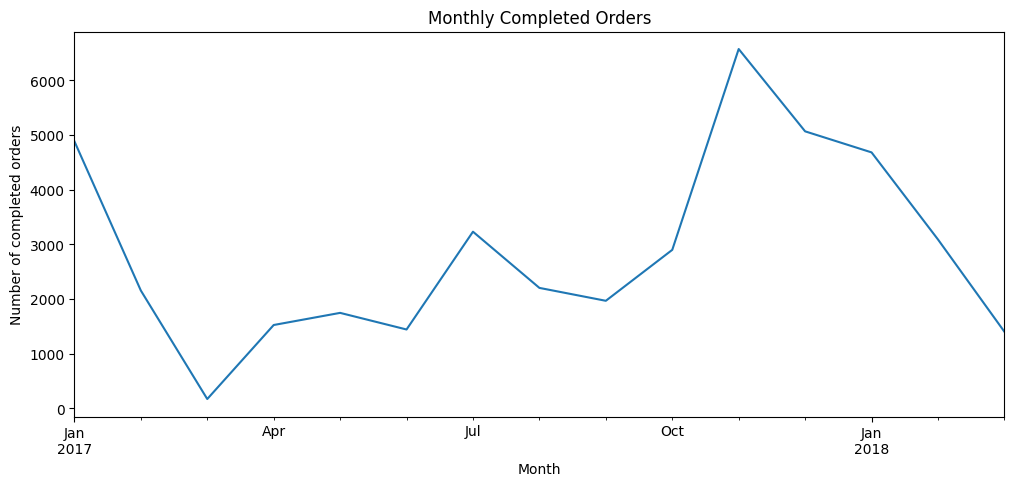

In [ ]:
ax = monthly_sales["orders"].plot(
    figsize=(12, 5),
    title="Monthly Completed Orders"
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of completed orders")

Text(0, 0.5, 'Revenue')

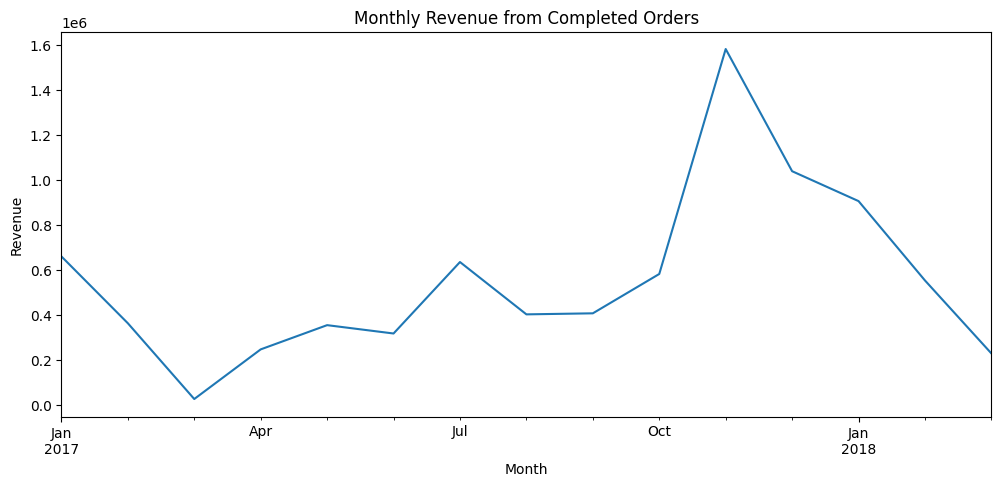

In [ ]:
ax = monthly_sales["revenue"].plot(
    figsize=(12, 5),
    title="Monthly Revenue from Completed Orders"
)

ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

In [ ]:
black_friday = completed_orderlines.loc[
    completed_orderlines["created_date"].between("2017-11-20", "2017-11-27")
]

christmas = completed_orderlines.loc[
    completed_orderlines["created_date"].between("2017-12-01", "2017-12-24")
]

normal_period = completed_orderlines.loc[
    ~completed_orderlines["created_date"].between("2017-11-20", "2017-11-27") &
    ~completed_orderlines["created_date"].between("2017-12-01", "2017-12-24")
]

In [ ]:
special_dates_summary = pd.DataFrame({
    "period": ["Black Friday Week", "Christmas Period", "Normal Period"],
    "orders": [
        black_friday["order_id"].nunique(),
        christmas["order_id"].nunique(),
        normal_period["order_id"].nunique()
    ],
    "items_sold": [
        black_friday["product_quantity"].sum(),
        christmas["product_quantity"].sum(),
        normal_period["product_quantity"].sum()
    ],
    "revenue": [
        black_friday["revenue"].sum(),
        christmas["revenue"].sum(),
        normal_period["revenue"].sum()
    ]
})

special_dates_summary

,period,orders,items_sold,revenue
0,Black Friday Week,3747,5959,971769.63
1,Christmas Period,3385,4685,698427.85
2,Normal Period,35932,53323,6628012.04


In [ ]:
special_dates_summary["days"] = [8, 24, normal_period["created_date"].dt.date.nunique()]

special_dates_summary["orders_per_day"] = (
    special_dates_summary["orders"] / special_dates_summary["days"]
)

special_dates_summary["items_per_day"] = (
    special_dates_summary["items_sold"] / special_dates_summary["days"]
)

special_dates_summary["revenue_per_day"] = (
    special_dates_summary["revenue"] / special_dates_summary["days"]
)

special_dates_summary

,period,orders,items_sold,revenue,days,orders_per_day,items_per_day,revenue_per_day
0,Black Friday Week,3747,5959,971769.63,8,468.375000,744.875000,121471.203750
1,Christmas Period,3385,4685,698427.85,24,141.041667,195.208333,29101.160417
2,Normal Period,35932,53323,6628012.04,408,88.068627,130.693627,16245.127549


<Axes: title={'center': 'Revenue per Day by Period'}, xlabel='period'>

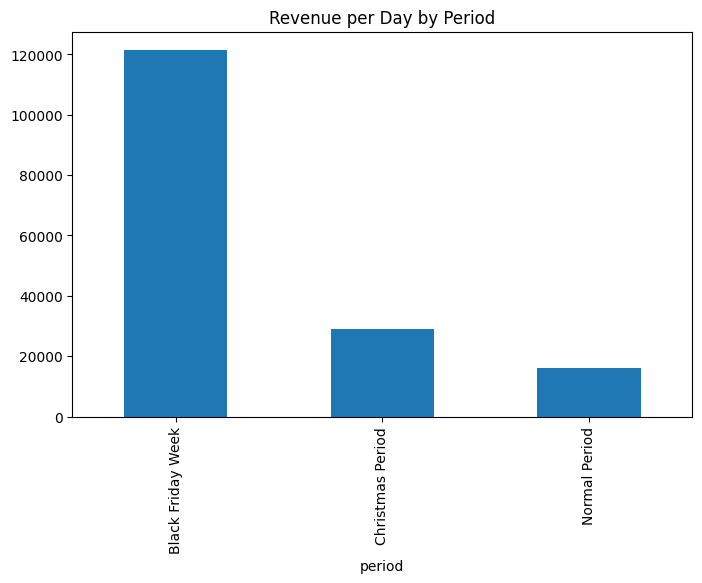

In [ ]:
special_dates_summary.plot(
    x="period",
    y="revenue_per_day",
    kind="bar",
    figsize=(8, 5),
    title="Revenue per Day by Period",
    legend=False
)

Sales are strongly seasonal. November and December are the strongest months, and Black Friday is the biggest sales driver.
November 2017 had the highest performance, with 6,575 completed orders, 10,160 items sold, and €1.58M revenue. Black Friday week was especially strong, generating about €121K revenue per day, compared with about €16K per day during normal periods. Christmas also improved sales, but less strongly than Black Friday.

# **4. What is the price distribution across categories?**

### Answer: Price Distribution Across Categories

Product prices vary strongly across product types. Some product types have very high typical prices, with median prices above €1,000, while others are mainly low-price categories with median prices below €50.

The average price is often higher than the median price, which indicates that several categories contain expensive outliers. For example, type `11935397` has a median price of €209.99 but an average price of €748.04 and a maximum price above €10,000.

This means the product catalog contains both low-price accessories and high-price products. Therefore, Eniac should not apply one single discount strategy across all categories. Discounts should be adjusted by category and price level.

# **5. How could data collection be improved?**

In [ ]:
# This is a text answer based on what we found during cleaning:
#
# 1. PRICE FORMAT: Use a single, consistent number format. The mix of European (1.237,86) and American (1,237.86) formats
#    caused 12.3% of orderlines to have corrupted prices.
#
# 2. PROMO_PRICE: 42% of promo_price values were corrupted. This column had to be dropped entirely, losing visibility
#    into the company's intended promotional pricing.
#
# 3. PRODUCT CATEGORIES: The "type" column uses numeric codes with no labels. Human-readable category names (e.g. "laptop",
#    "accessory", "charger") would enable better analysis.
#
# 4. DUPLICATE PRODUCTS: 8,746 duplicate rows in products table suggest issues in the data pipeline. Add unique constraints.
#
# 5. ORDER STATES: Clarify what each state means and when transitions happen. Some orders seem stuck in intermediate states.
# State management improvement:Pending and Shopping Basket orders remain open, needs automatic expiration — e.g Pending → Cancelled after 30 days
#
# 6. SHIPPING COSTS: Store shipping cost as a separate column in orders, not bundled into total_paid. This would make
#   revenue analysis more accurate.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ===== VISUALIZATION SETUP =====
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette(["#2a9d8f", "#ec9750"])

# Custom colors for easy reference
TEAL = "#2a9d8f"
ORANGE = "#ec9750"

plt.rcParams["figure.facecolor"] = "#fafafa"
plt.rcParams["axes.facecolor"] = "#fafafa"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# **6. Is the Board's claim true? Did orders increase while revenue decreased over time?**

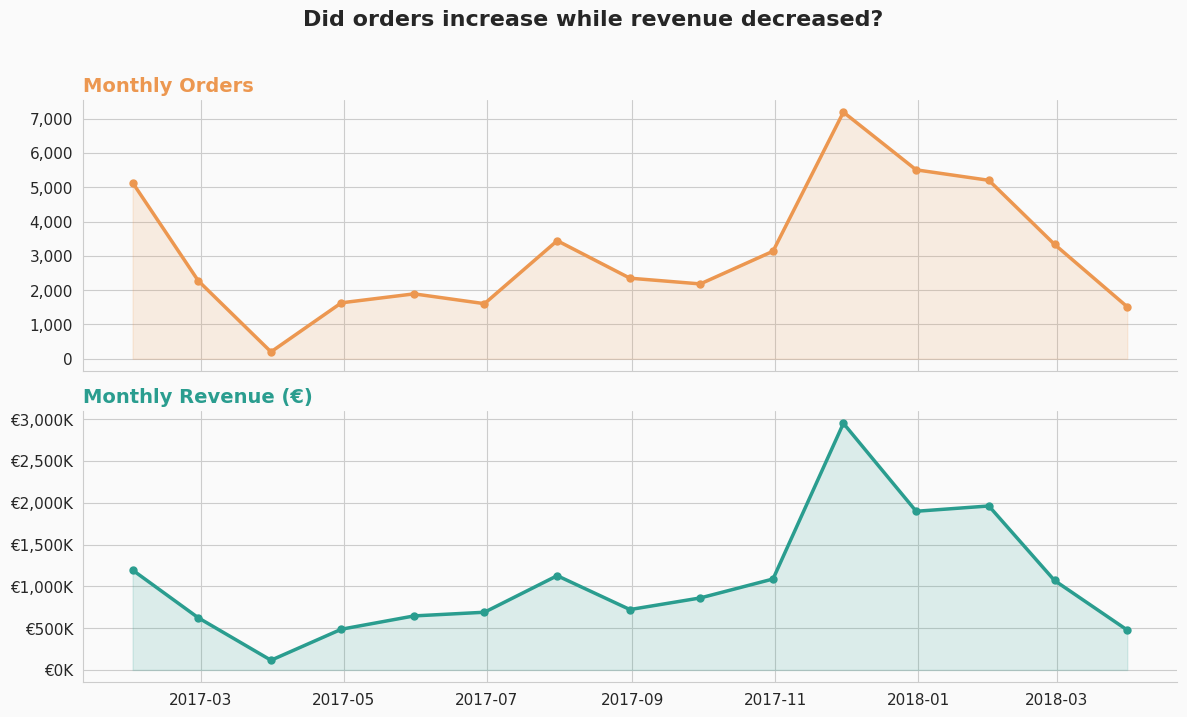

In [ ]:
import matplotlib.ticker as mticker

monthly_trend = (
    completed_orders
    .resample("ME", on="created_date")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_paid", "sum")
    )
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Orders ---
ax1.plot(monthly_trend.index, monthly_trend["order_count"],
         color="#ec9750", linewidth=2.5, marker="o", markersize=5)
ax1.fill_between(monthly_trend.index, monthly_trend["order_count"],
                 alpha=0.15, color="#ec9750")
ax1.set_title("Monthly Orders", fontsize=14, fontweight="bold",
              color="#ec9750", loc="left")
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.tick_params(labelsize=11)

# --- Revenue ---
ax2.plot(monthly_trend.index, monthly_trend["total_revenue"],
         color="#2a9d8f", linewidth=2.5, marker="o", markersize=5)
ax2.fill_between(monthly_trend.index, monthly_trend["total_revenue"],
                 alpha=0.15, color="#2a9d8f")
ax2.set_title("Monthly Revenue (€)", fontsize=14, fontweight="bold",
              color="#2a9d8f", loc="left")
ax2.spines[["top", "right"]].set_visible(False)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:,.0f}K"))
ax2.tick_params(labelsize=11)

fig.suptitle("Did orders increase while revenue decreased?",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

# **7. Do discounted products lead to larger orders?**

In [ ]:
# Calculate line total per orderline
merged_df["line_total"] = merged_df["unit_price"] * merged_df["product_quantity"]

# For each order: has discount? basket size? total spent?
order_summary = (
    merged_df
    .groupby("order_id")
    .agg(
        has_discount=("is_discounted", "any"),
        basket_size=("product_quantity", "sum"),
        order_total=("line_total", "sum")
    )
)

# Compare the two groups
comparison = (
    order_summary
    .groupby("has_discount")
    .agg(
        num_orders=("basket_size", "count"),
        avg_basket_size=("basket_size", "mean"),
        avg_order_total=("order_total", "mean"),
    )
    .round(2)
)

print(comparison)

              num_orders  avg_basket_size  avg_order_total
has_discount                                              
False               2436             1.23            177.9
True               40133             1.50            191.6


In [ ]:
# Analysis
no_disc = comparison.loc[False]
has_disc = comparison.loc[True]
total_orders = no_disc["num_orders"] + has_disc["num_orders"]

pct_with_discount = 100 * has_disc["num_orders"] / total_orders
basket_diff = 100 * (has_disc["avg_basket_size"] / no_disc["avg_basket_size"] - 1)
total_diff = 100 * (has_disc["avg_order_total"] / no_disc["avg_order_total"] - 1)

print(f"\n{'='*60}")
print(f"ANALYSIS")
print(f"{'='*60}")
print(f"\n{pct_with_discount:.1f}% of orders ({int(has_disc['num_orders'])} out of {int(total_orders)}) contain at least one discounted product.")
print(f"\nBasket size: {has_disc['avg_basket_size']:.2f} items (discount) vs {no_disc['avg_basket_size']:.2f} items (no discount) → +{basket_diff:.1f}% more products")
print(f"Order total: €{has_disc['avg_order_total']:.2f} (discount) vs €{no_disc['avg_order_total']:.2f} (no discount) → +{total_diff:.1f}% more spending")
print(f"\n{'='*60}")
print(f"CONCLUSION")
print(f"{'='*60}")
print(f"Discounted orders have slightly larger baskets and higher totals.")
print(f"This supports the Marketing Team's argument that discounts")
print(f"encourage customers to buy more.")
print(f"\nCAVEAT: Only {int(no_disc['num_orders'])} orders have no discount at all,")
print(f"vs {int(has_disc['num_orders'])} with discount. The comparison is imbalanced.")


ANALYSIS

94.3% of orders (40133 out of 42569) contain at least one discounted product.

Basket size: 1.50 items (discount) vs 1.23 items (no discount) → +22.0% more products
Order total: €191.60 (discount) vs €177.90 (no discount) → +7.7% more spending

CONCLUSION
Discounted orders have slightly larger baskets and higher totals.
This supports the Marketing Team's argument that discounts
encourage customers to buy more.

CAVEAT: Only 2436 orders have no discount at all,
vs 40133 with discount. The comparison is imbalanced.


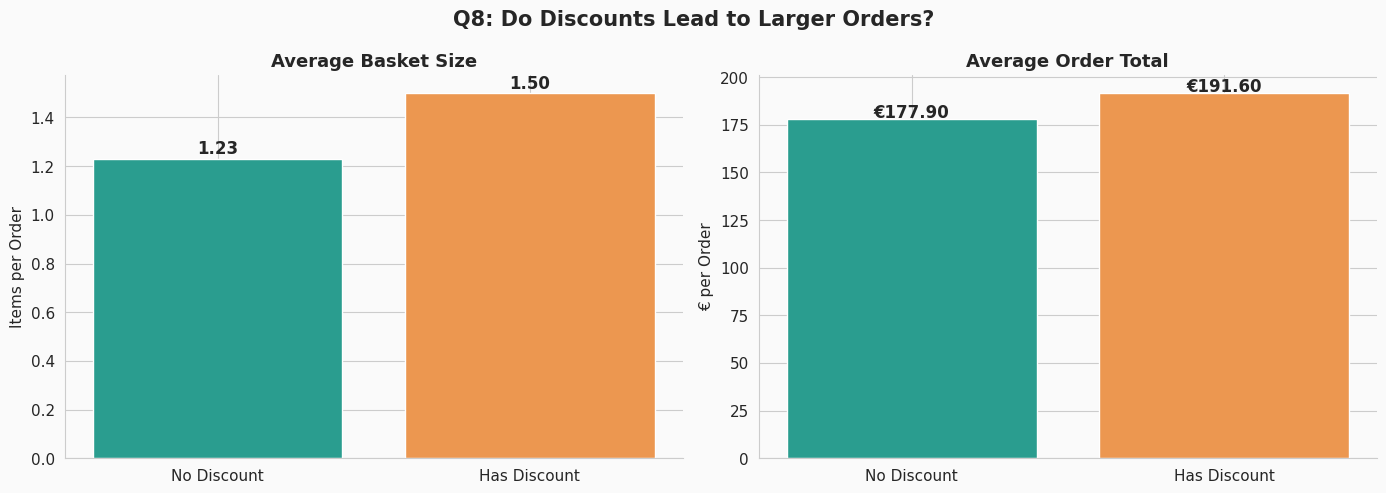

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["No Discount", "Has Discount"]

# Chart 1: Basket size
axes[0].bar(labels, comparison["avg_basket_size"], color=[TEAL, ORANGE])
axes[0].set_title("Average Basket Size", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Items per Order")
for i, v in enumerate(comparison["avg_basket_size"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold", fontsize=12)

# Chart 2: Order total
axes[1].bar(labels, comparison["avg_order_total"], color=[TEAL, ORANGE])
axes[1].set_title("Average Order Total", fontsize=13, fontweight="bold")
axes[1].set_ylabel("€ per Order")
for i, v in enumerate(comparison["avg_order_total"]):
    axes[1].text(i, v + 1, f"€{v:.2f}", ha="center", fontweight="bold", fontsize=12)

fig.suptitle("Q8: Do Discounts Lead to Larger Orders?", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

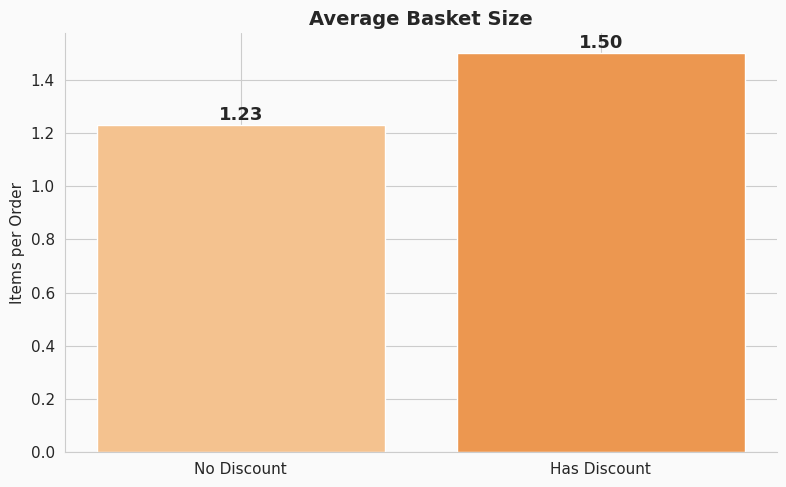

In [ ]:
# Chart 1: Basket size — two shades of orange
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["No Discount", "Has Discount"]
ax.bar(labels, comparison["avg_basket_size"], color=["#f4c28f", "#ec9750"])
ax.set_title("Average Basket Size", fontsize=14, fontweight="bold")
ax.set_ylabel("Items per Order")
for i, v in enumerate(comparison["avg_basket_size"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

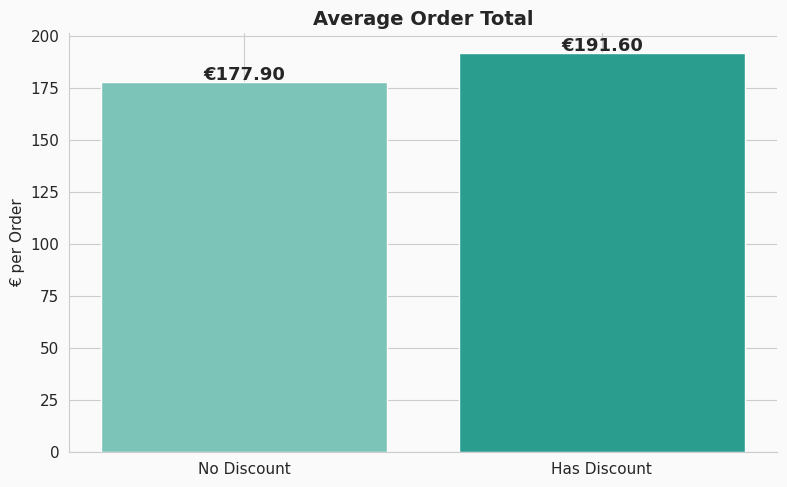

In [ ]:
# Chart 2: Order total — two shades of teal
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["No Discount", "Has Discount"]
ax.bar(labels, comparison["avg_order_total"], color=["#7dc4b8", "#2a9d8f"])
ax.set_title("Average Order Total", fontsize=14, fontweight="bold")
ax.set_ylabel("€ per Order")
for i, v in enumerate(comparison["avg_order_total"]):
    ax.text(i, v + 1, f"€{v:.2f}", ha="center", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

                     mean  median  count
order_type                              
Full Price     182.762545  77.495   2436
With Discount  197.324082  99.980  40133


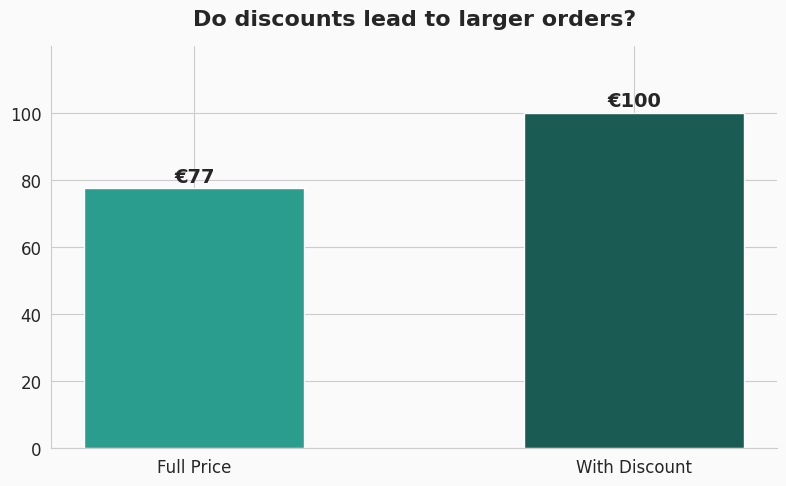

In [ ]:
# Step 1: Flag each order as discounted or not
order_discount_flag = (
    merged_df
    .groupby("order_id")["is_discounted"]
    .any()  # True if at least one orderline is discounted
    .reset_index()
    .rename(columns={"is_discounted": "has_discount"})
)

# Step 2: Merge with completed_orders to get total_paid
order_comparison = order_discount_flag.merge(
    completed_orders[["order_id", "total_paid"]],
    on="order_id",
    how="inner"
)

# Step 3: Label for the chart
order_comparison["order_type"] = order_comparison["has_discount"].map({
    True: "With Discount",
    False: "Full Price"
})

# Step 4: Summary stats
print(order_comparison.groupby("order_type")["total_paid"].agg(["mean", "median", "count"]))

# Step 5: Chart — median is better here (outliers won't skew it)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

medians = order_comparison.groupby("order_type")["total_paid"].median()
colors = ["#2a9d8f", "#1a5c53"]

bars = ax.bar(medians.index, medians.values, color=colors, width=0.5, edgecolor="white")

# Data labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"€{bar.get_height():,.0f}",
            ha="center", fontsize=14, fontweight="bold")

ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("Do discounts lead to larger orders?",
             fontsize=16, fontweight="bold", pad=15)
ax.tick_params(labelsize=12)
ax.set_ylim(0, medians.max() * 1.2)

plt.tight_layout()
plt.show()

# **8. What is the time period that the dataset covers?**

In [ ]:
print(f"From: {completed_orders['created_date'].min()}")
print(f"To:   {completed_orders['created_date'].max()}")

From: 2017-01-01 01:51:47
To:   2018-03-14 12:03:52


## **9. What is the overall revenue for that time?**

In [ ]:
total_revenue = completed_orders["total_paid"].sum()
print(f"Total revenue: €{total_revenue:,.2f}")

Total revenue: €15,910,079.24
